# Linear Regression with the Best Single Predictor

This notebook compares one-predictor linear regression models for `sampregdata.csv`, selects the predictor with the best held-out test $R^2$, and evaluates the final model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

data_path = Path('Data/sampregdata.csv')
if not data_path.exists():
    data_path = Path.cwd() / 'Data' / 'sampregdata.csv'

data = pd.read_csv(data_path)
data = data.drop(columns=data.columns[0])
predictors = [column for column in data.columns if column != 'y']
target = 'y'
data.head()

,x1,x2,x3,x4,y
0,7.331693,9.660958,-2.981869,5.214284,-2.311878
1,16.888609,9.546231,18.440459,11.804018,0.994307
2,8.280643,6.442062,-0.225791,6.493211,-5.253876
3,3.827778,3.741506,-2.850664,-0.226420,20.056798
4,9.675971,4.385008,8.344576,5.979043,9.577914


## Compare one-feature models

All candidate features use the same reproducible 80/20 train/test split. The feature with the largest test $R^2$ is selected.

In [2]:
X = data[predictors]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []
for feature in predictors:
    model = LinearRegression()
    model.fit(X_train[[feature]], y_train)
    predictions = model.predict(X_test[[feature]])
    results.append({
        'feature': feature,
        'test_r2': r2_score(y_test, predictions),
        'test_rmse': mean_squared_error(y_test, predictions) ** 0.5,
    })

comparison = pd.DataFrame(results).sort_values('test_r2', ascending=False).reset_index(drop=True)
best_feature = comparison.loc[0, 'feature']
comparison

,feature,test_r2,test_rmse
0,x4,0.268554,8.766565
1,x2,0.206747,9.129445
2,x3,0.158234,9.404467
3,x1,-0.004270,10.272205


## Fit and evaluate the final model

The final model uses the selected feature and is evaluated on the untouched test set.

In [3]:
final_model = LinearRegression()
final_model.fit(X_train[[best_feature]], y_train)
final_predictions = final_model.predict(X_test[[best_feature]])

evaluation = pd.DataFrame({
    'best_feature': [best_feature],
    'coefficient': [final_model.coef_[0]],
    'intercept': [final_model.intercept_],
    'test_rmse': [mean_squared_error(y_test, final_predictions) ** 0.5],
    'test_r2': [r2_score(y_test, final_predictions)],
})
evaluation

,best_feature,coefficient,intercept,test_rmse,test_r2
0,x4,-1.242954,8.696653,8.766565,0.268554


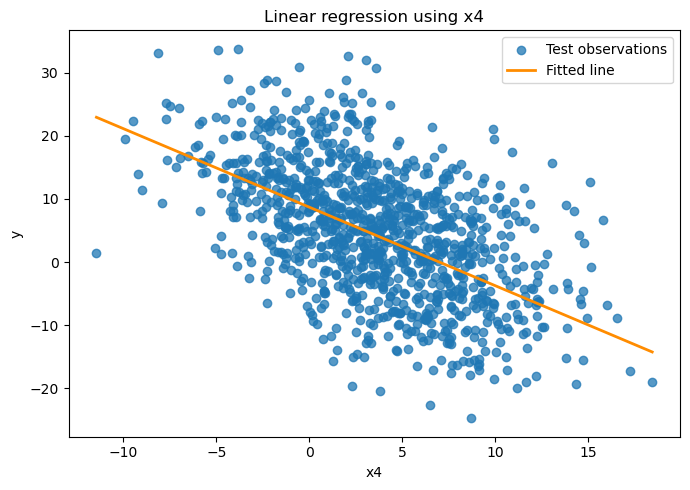

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test[best_feature], y_test, alpha=0.75, label='Test observations')
line_x = pd.DataFrame({best_feature: sorted(X_test[best_feature])})
line_y = final_model.predict(line_x)
plt.plot(line_x[best_feature], line_y, color='darkorange', linewidth=2, label='Fitted line')
plt.xlabel(best_feature)
plt.ylabel(target)
plt.title(f'Linear regression using {best_feature}')
plt.legend()
plt.tight_layout()
plt.show()